BOOSTING REGRESSOR

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
# importing thee data 
Insurance_rs_original = pd.read_csv("Health_Insurance_Cleaned.csv")
Insurance_rs = Insurance_rs_original.copy()
Insurance_rs

,Age,Bmi,Children,Charges,Sex,Smoker,Region
0,-0.833333,-0.297265,-0.676573,0.474944,0,1,-0.078062
1,-0.875000,0.400713,0.000000,-1.302256,1,0,-0.000210
2,-0.458333,0.309156,0.525592,-0.586103,1,0,-0.000210
3,-0.250000,-0.914982,-0.676573,0.692488,1,0,-0.045324
4,-0.291667,-0.180737,-0.676573,-0.694133,1,0,-0.045324
...,...,...,...,...,...,...,...
1332,0.458333,0.067776,0.525592,0.097395,1,0,-0.045324
1333,-0.875000,0.180737,-0.676573,-1.119463,0,0,0.029602
1334,-0.875000,0.766944,-0.676573,-1.344439,0,0,-0.000210
1335,-0.750000,-0.546968,-0.676573,-1.189701,0,0,-0.078062


In [3]:
# Checking info of the data
Insurance_rs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1337 non-null   float64
 1   Bmi       1337 non-null   float64
 2   Children  1337 non-null   float64
 3   Charges   1337 non-null   float64
 4   Sex       1337 non-null   int64  
 5   Smoker    1337 non-null   int64  
 6   Region    1337 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.2 KB


In [4]:
# Checking for null values
Insurance_rs.isnull().sum()

Age         0
Bmi         0
Children    0
Charges     0
Sex         0
Smoker      0
Region      0
dtype: int64

In [5]:
# Checking for null values
print(Insurance_rs.duplicated().sum())

0


In [6]:
# Spliting data into features Matrix and target vector
X = Insurance_rs.drop(columns = ["Charges"], axis = "columns")
y = Insurance_rs["Charges"]

In [7]:
# Creating instances of all boosting algorithms for Regression
adabr = AdaBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
xgbr = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
lgbmr = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
catr = CatBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose = 0)

CROSS VAL SCORE

In [8]:
# defining the number of folds for cross validation
kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [9]:
# performing k-fold cross-validation
# we use cross_val_score() to automatically split data, train and evaluate the model across all folds.
# it returns the accuracy for each fold
adar_scores_kf = cross_val_score(adabr, X,y, cv = kfold, scoring = "r2")
xgbr_scores_kf = cross_val_score(xgbr, X,y, cv = kfold, scoring = "r2")
lgbmr_scores_kf = cross_val_score(lgbmr, X,y, cv = kfold, scoring = "r2")
catr_scores_kf = cross_val_score(catr, X,y, cv = kfold, scoring = "r2")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score -0.029553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score -0.017325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 107

In [10]:
adar_scores_kf

array([0.81721227, 0.72945106, 0.74950801, 0.75124854, 0.77680223])

In [11]:
# Adaboost
print("K-fold cross validation results (r2): ")
for i, result in enumerate(adar_scores_kf, 1):
    print(f" Fold{i}: {result * 100:.2f}%")

print(f" Mean r2: {adar_scores_kf.mean()* 100:.2f}%")
print(f" Standard Deviation: {adar_scores_kf.std() :.2f}\n")

K-fold cross validation results (r2): 
 Fold1: 81.72%
 Fold2: 72.95%
 Fold3: 74.95%
 Fold4: 75.12%
 Fold5: 77.68%
 Mean r2: 76.48%
 Standard Deviation: 0.03



In [12]:
# Xgboost
print("K-fold cross validation results (r2): ")
for i, result in enumerate(xgbr_scores_kf, 1):
    print(f" Fold{i}: {result * 100:.2f}%")

print(f" Mean r2: {xgbr_scores_kf.mean()* 100:.2f}%")
print(f"    Standard Deviation: {xgbr_scores_kf.std() :.2f}\n")

K-fold cross validation results (r2): 
 Fold1: 81.47%
 Fold2: 74.81%
 Fold3: 76.30%
 Fold4: 77.60%
 Fold5: 79.63%
 Mean r2: 77.96%
    Standard Deviation: 0.02



In [13]:
# Lgboost
print("K-fold cross validation results (r2): ")
for i, result in enumerate(lgbmr_scores_kf, 1):
    print(f" Fold{i}: {result * 100:.2f}%")

print(f" Mean r2: {lgbmr_scores_kf.mean()* 100:.2f}%")
print(f"    Standard Deviation: {lgbmr_scores_kf.std() :.2f}\n")

K-fold cross validation results (r2): 
 Fold1: 83.16%
 Fold2: 75.16%
 Fold3: 75.25%
 Fold4: 78.54%
 Fold5: 79.80%
 Mean r2: 78.38%
    Standard Deviation: 0.03



In [14]:
# Catboost
print("K-fold cross validation results (r2): ")
for i, result in enumerate(catr_scores_kf, 1):
    print(f" Fold{i}: {result * 100:.2f}%")

print(f" Mean r2: {catr_scores_kf.mean()* 100:.2f}%")
print(f"    Standard Deviation: {catr_scores_kf.std() :.2f}\n")

K-fold cross validation results (r2): 
 Fold1: 86.57%
 Fold2: 76.62%
 Fold3: 78.43%
 Fold4: 82.51%
 Fold5: 82.96%
 Mean r2: 81.42%
    Standard Deviation: 0.04



K-Fold cross-validation was used to evaluate each model's ability to generalise across different subsets of the data. Catboost achieved the highest mean r2 score at 81.42%, followed closely by lightboost.
An r2 of 81% means catboost explains 81% of the variance in insurance charges across all five folds,
which is a strong result for a health data due to its unpredictability and noise.
The standard deviation across all folds indicates how consistent the model is regardless of which subset of data it sees

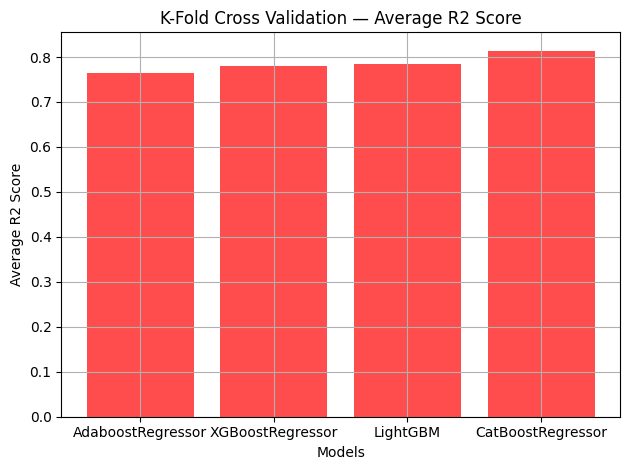

In [15]:
# visualizing the performance of each model using the bars for both cross validation techniques
models = ["AdaboostRegressor", "XGBoostRegressor", "LightGBM", "CatBoostRegressor"]
r2_kf = [adar_scores_kf.mean(), xgbr_scores_kf.mean(), lgbmr_scores_kf.mean(), catr_scores_kf.mean()]

# create the figure(size of each of the subplots) and subplots
figsize = (12, 6)
plt.bar(models, r2_kf, color="r", alpha=0.7)
plt.title("K-Fold Cross Validation — Average R2 Score")
plt.xlabel("Models")
plt.ylabel("Average R2 Score")
plt.grid(True)
plt.tight_layout()
plt.show()

The chart gives a visual comparison of each model's average r2 score across the 5 folds.
Catboost and Lgboost visibly outperformed adaboost and xgboost.
The differences may appear small visually but can be meaningful depending on
how the model is applied and when predicting real-world costs.

CROSS VALIDATE

In [16]:
# performing k-fold cross validation using cross_validate function
adabr_scores_cv = cross_validate(adabr, X,y, cv = kfold, scoring = ["r2", "neg_mean_squared_error", "neg_mean_absolute_error"], return_estimator = True)
xbr_scores_cv = cross_validate(xgbr, X,y, cv = kfold, scoring = ["r2", "neg_mean_squared_error", "neg_mean_absolute_error"], return_estimator = True)
lgbmr_scores_cv = cross_validate(lgbmr, X,y, cv = kfold, scoring = ["r2", "neg_mean_squared_error", "neg_mean_absolute_error"], return_estimator = True)
catr_scores_cv = cross_validate(catr, X,y, cv = kfold, scoring = ["r2", "neg_mean_squared_error", "neg_mean_absolute_error"], return_estimator = True)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score -0.029553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score -0.017325
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 6
[LightGBM] [Info] Start training f

In [17]:
adabr_scores_cv

{'fit_time': array([0.31404662, 0.45687675, 0.38262129, 0.40248299, 0.39492726]),
 'score_time': array([0.02105093, 0.02865124, 0.02482533, 0.02549577, 0.02462173]),
 'estimator': [AdaBoostRegressor(learning_rate=0.05, n_estimators=500, random_state=42),
  AdaBoostRegressor(learning_rate=0.05, n_estimators=500, random_state=42),
  AdaBoostRegressor(learning_rate=0.05, n_estimators=500, random_state=42),
  AdaBoostRegressor(learning_rate=0.05, n_estimators=500, random_state=42),
  AdaBoostRegressor(learning_rate=0.05, n_estimators=500, random_state=42)],
 'test_r2': array([0.81721227, 0.72945106, 0.74950801, 0.75124854, 0.77680223]),
 'test_neg_mean_squared_error': array([-0.10627517, -0.14364292, -0.12986922, -0.12571777, -0.11458248]),
 'test_neg_mean_absolute_error': array([-0.24068584, -0.27878811, -0.27250666, -0.25858268, -0.25420348])}

In [18]:
# Adaboost
print("K-Fold Cross Validation Results: ")
print(f"   Mean Squared Error  : {(-adabr_scores_cv["test_neg_mean_squared_error"]).mean():.2f}")
print(f"    Mean Absolute Error : {(-adabr_scores_cv["test_neg_mean_absolute_error"]).mean():.2f}")   
print(f"     Root Mean Squared Error : {np.sqrt(-adabr_scores_cv["test_neg_mean_squared_error"].mean()):.2f}")
print(f"      Coeffiecient of determination (R2-Score)   : {adabr_scores_cv["test_r2"].mean():.2f}")

K-Fold Cross Validation Results: 
   Mean Squared Error  : 0.12
    Mean Absolute Error : 0.26
     Root Mean Squared Error : 0.35
      Coeffiecient of determination (R2-Score)   : 0.76


In [19]:
# Xgboost
print("K-Fold Cross Validation Results: ")
print(f"   Mean Squared Error  : {(-xgbr_scores_cv['test_neg_mean_squared_error']).mean():.2f}")
print(f"    Mean Absolute Error : {(-xgbr_scores_cv['test_neg_mean_absolute_error']).mean():.2f}")   
print(f"     Root Mean Squared Error : {np.sqrt(-xgbr_scores_cv['test_neg_mean_squared_error'].mean()):.2f}")
print(f"      Coeffiecient of determination (R2-Score)   : {xgbr_scores_cv['test_r2'].mean():.2f}")

K-Fold Cross Validation Results: 
   Mean Squared Error  : 0.12
    Mean Absolute Error : 0.18
     Root Mean Squared Error : 0.34
      Coeffiecient of determination (R2-Score)   : 0.78


In [20]:
# LGboost
print("K-Fold Cross Validation Results: ")
print(f"   Mean Squared Error  : {(-lgbmr_scores_cv['test_neg_mean_squared_error']).mean():.2f}")
print(f"    Mean Absolute Error : {(-lgbmr_scores_cv['test_neg_mean_absolute_error']).mean():.2f}")   
print(f"     Root Mean Squared Error : {np.sqrt(-lgbmr_scores_cv['test_neg_mean_squared_error'].mean()):.2f}")
print(f"      Coeffiecient of determination (R2-Score)   : {lgbmr_scores_cv['test_r2'].mean():.2f}")

K-Fold Cross Validation Results: 
   Mean Squared Error  : 0.11
    Mean Absolute Error : 0.19
     Root Mean Squared Error : 0.34
      Coeffiecient of determination (R2-Score)   : 0.78


In [21]:
# Catboost
print("K-Fold Cross Validation Results: ")
print(f"   Mean Squared Error  : {(-catr_scores_cv['test_neg_mean_squared_error']).mean():.2f}")
print(f"    Mean Absolute Error : {(-catr_scores_cv['test_neg_mean_absolute_error']).mean():.2f}")   
print(f"     Root Mean Squared Error : {np.sqrt(-catr_scores_cv['test_neg_mean_squared_error'].mean()):.2f}")
print(f"      Coeffiecient of determination (R2-Score)   : {catr_scores_cv['test_r2'].mean():.2f}")

K-Fold Cross Validation Results: 
   Mean Squared Error  : 0.10
    Mean Absolute Error : 0.16
     Root Mean Squared Error : 0.31
      Coeffiecient of determination (R2-Score)   : 0.81


Across all four error metrics, CatBoost consistently produced the lowest errors and the highest R² score, confirming it as the strongest model for this health insurance data.

MODEL BUILDING

In [22]:
# Train-test split — needed for model building stage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Retraining all models on the full training set and evaluating on the test set
models = {
    "AdaBoost" : AdaBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42),
    "XGBoost"  : XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42),
    "LightGBM" : LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42),
    "CatBoost" : CatBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=0)
}

for model_name, models in models.items():
    models.fit(X_train, y_train)
    y_pred = models.predict(X_test)

    print(f"\n{model_name} Results:")
    print(f"   MSE  : {mean_squared_error(y_test, y_pred):.2f}")
    print(f"    MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"     RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"      R2   : {r2_score(y_test, y_pred):.2f}")


AdaBoost Results:
   MSE  : 0.11
    MAE  : 0.25
     RMSE : 0.33
      R2   : 0.81

XGBoost Results:
   MSE  : 0.11
    MAE  : 0.17
     RMSE : 0.33
      R2   : 0.81
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score -0.029553

LightGBM Results:
   MSE  : 0.10
    MAE  : 0.19
     RMSE : 0.31
      R2   : 0.83

CatBoost Results:
   MSE  : 0.08
    MAE  : 0.16
     RMSE : 0.28
      R2   : 0.87


The models were retrained on the full training set and evaluated on the unseen test set. This step confirms whether the performance seen during cross-validation holds up on new data.
CatBoost again produced the best results across all metrics, consistent with cross-validation findings. This consistency between cross-validation and test set performance suggests the model generalises well and is not overfitting to the training data.